In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:




import os, glob, random, json, zipfile
import numpy as np
import pandas as pd
!pip install tensorflow
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
zip_path = "/content/drive/MyDrive/Colab Notebooks/Parkinson_project_using_mobile_net_V2_inclue_F_base_T_F_/Parkinson_dataset.zip"
extract_path = "/content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_single_model_unzip_here"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully")

Dataset unzipped successfully


In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_single_model_unzip_here"):
    print("ROOT:", root)
    print("DIRS:", dirs[:10])
    print("FILES:", files[:5])
    print("-" * 60)

ROOT: /content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_single_model_unzip_here
DIRS: ['Parkinson_dataset']
FILES: []
------------------------------------------------------------
ROOT: /content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_single_model_unzip_here/Parkinson_dataset
DIRS: ['healthy_dataset', 'parkinson_dataset']
FILES: []
------------------------------------------------------------
ROOT: /content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_single_model_unzip_here/Parkinson_dataset/healthy_dataset
DIRS: ['control_png']
FILES: []
------------------------------------------------------------
ROOT: /content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_single_model_unzip_here/Parkinson_dataset/healthy_dataset/control_png
DIRS: []
FILES: ['PPMI_113447_MR_SAG_3D_T1-weighted_br_raw_20220428195136437_168_S1128963_I1575063.png', 'PPMI_113447_MR_SAG_3D_T1-weighted_br_raw_20220428195139465_10_S1128963_I1575063.png', 'PPMI_113447_MR_SAG_3D_T1-weighted_br_raw_20220428195140145_

In [ ]:
DATASET_DIR = "/content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_dataset_unzipped_here/Parkinson_dataset"  # Corrected to point to the unzipped dataset base

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos"

MODEL_DIR = os.path.join(SAVE_DIR, "models")
HISTORY_DIR = os.path.join(SAVE_DIR, "history_files")
GRAPH_DIR = os.path.join(SAVE_DIR, "graphs")
CM_DIR = os.path.join(SAVE_DIR, "confusion_matrices")

for d in [SAVE_DIR, MODEL_DIR, HISTORY_DIR, GRAPH_DIR, CM_DIR]:
    os.makedirs(d, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 35

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("Dataset path:", DATASET_DIR)
print("Save path:", SAVE_DIR)

Dataset path: /content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_dataset_unzipped_here/Parkinson_dataset
Save path: /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos


In [ ]:
# Corrected DATASET_DIR to match the actual extraction path
ACTUAL_DATASET_DIR = "/content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_single_model_unzip_here/Parkinson_dataset"

healthy = []
parkinson = []

for ext in ["*.png", "*.jpg", "*.jpeg", "*.PNG", "*.JPG", "*.JPEG"]:
    healthy.extend(glob.glob(os.path.join(ACTUAL_DATASET_DIR, "healthy_dataset", "control_png", ext)))
    parkinson.extend(glob.glob(os.path.join(ACTUAL_DATASET_DIR, "parkinson_dataset", "pd_png", ext)))

print("Healthy images found:", len(healthy))
print("Parkinson images found:", len(parkinson))

assert len(healthy) > 0, f"Healthy images not found at {ACTUAL_DATASET_DIR}"
assert len(parkinson) > 0, f"Parkinson images not found at {ACTUAL_DATASET_DIR}"

paths = healthy + parkinson
labels = [0] * len(healthy) + [1] * len(parkinson)

print("Total images:", len(paths))

Healthy images found: 4186
Parkinson images found: 5560
Total images: 9746


### Verifying contents of the zip file

Let's inspect the `Parkinson_dataset.zip` file directly to see its contents. This will list all the files contained within the archive.

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/Parkinson_project_using_mobile_net_V2_inclue_F_base_T_F_/Parkinson_dataset.zip"

healthy_count_zip = 0
parkinson_count_zip = 0

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()
    print(f"Total files in zip: {len(file_list)}")
    print("First 10 files in zip:\n")
    for i, member in enumerate(file_list):
        if i < 10:
            print(member)
        if 'healthy_dataset/control_png' in member and member.endswith('.png'):
            healthy_count_zip += 1
        elif 'parkinson_dataset/pd_png' in member and member.endswith('.png'):
            parkinson_count_zip += 1

print(f"\nHealthy .png files in zip: {healthy_count_zip}")
print(f"Parkinson .png files in zip: {parkinson_count_zip}")


Total files in zip: 11125
First 10 files in zip:

Parkinson_dataset/
Parkinson_dataset/healthy_dataset/
Parkinson_dataset/healthy_dataset/control_png/
Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_000.png
Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_001.png
Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_002.png
Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_003.png
Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_004.png
Parkinson_dataset/healthy_dataset/control_png/PPMI_100890_MR_3D_T1-weighted_br_raw_20210916214027681_1_S1063522_I1493049_slice_005.png
Parkinson_dataset/healthy_dataset/contr

### Verify image counts directly from the file system

To confirm the number of `.png` files in each directory, you can use `ls -lR | grep -c .png` commands in the terminal (or directly in a Colab cell prefixed with `!` to run as a shell command).

This will give you a definitive count of the `.png` files that `glob` is picking up.

In [ ]:
print('Counting .png files in healthy_dataset:')
!ls -lR "{DATASET_DIR}/Parkinson_dataset/healthy_dataset/control_png" | grep -c '.png'

print('\nCounting .png files in parkinson_dataset:')
!ls -lR "{DATASET_DIR}/Parkinson_dataset/parkinson_dataset/pd_png" | grep -c '.png'

Counting .png files in healthy_dataset:
ls: cannot access '/content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_dataset_unzipped_here/Parkinson_dataset/Parkinson_dataset/healthy_dataset/control_png': No such file or directory
0

Counting .png files in parkinson_dataset:
ls: cannot access '/content/drive/MyDrive/Colab Notebooks/Parkinson_vgg16_dataset_unzipped_here/Parkinson_dataset/Parkinson_dataset/parkinson_dataset/pd_png': No such file or directory
0


In [ ]:
train_p, temp_p, train_l, temp_l = train_test_split(
    paths,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p,
    temp_l,
    test_size=0.5,
    stratify=temp_l,
    random_state=42
)

train_df = pd.DataFrame({
    "filename": train_p,
    "label": [str(x) for x in train_l]
})

val_df = pd.DataFrame({
    "filename": val_p,
    "label": [str(x) for x in val_l]
})

test_df = pd.DataFrame({
    "filename": test_p,
    "label": [str(x) for x in test_l]
})

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nTrain label count:")
print(train_df["label"].value_counts())

print("\nValidation label count:")
print(val_df["label"].value_counts())

print("\nTest label count:")
print(test_df["label"].value_counts())

Train: 6822
Validation: 1462
Test: 1462

Train label count:
label
1    3892
0    2930
Name: count, dtype: int64

Validation label count:
label
1    834
0    628
Name: count, dtype: int64

Test label count:
label
1    834
0    628
Name: count, dtype: int64


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

def make_generators():
    train_gen = train_datagen.flow_from_dataframe(
        train_df,
        x_col="filename",
        y_col="label",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=True
    )

    val_gen = val_test_datagen.flow_from_dataframe(
        val_df,
        x_col="filename",
        y_col="label",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    test_gen = val_test_datagen.flow_from_dataframe(
        test_df,
        x_col="filename",
        y_col="label",
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_gen, val_gen, test_gen

train_gen, val_gen, test_gen = make_generators()

print("Class indices:", train_gen.class_indices)

Found 6822 validated image filenames belonging to 2 classes.
Found 1462 validated image filenames belonging to 2 classes.
Found 1462 validated image filenames belonging to 2 classes.
Class indices: {'0': 0, '1': 1}


In [ ]:
class SaveHistoryEveryEpoch(Callback):

    def __init__(self, model_name):
        super().__init__()
        self.model_name = model_name
        self.history_data = {}

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}

        for key, value in logs.items():
            self.history_data.setdefault(key, []).append(float(value))

        csv_path = os.path.join(
            HISTORY_DIR,
            f"{self.model_name}_history_epoch_by_epoch.csv"
        )

        json_path = os.path.join(
            HISTORY_DIR,
            f"{self.model_name}_history_epoch_by_epoch.json"
        )

        pd.DataFrame(self.history_data).to_csv(csv_path, index=False)

        with open(json_path, "w") as f:
            json.dump(self.history_data, f)

        print(f"History saved after epoch {epoch + 1}")

In [ ]:
def train_model(model, model_name, train_gen, val_gen):

    best_model_path = os.path.join(
        MODEL_DIR,
        f"{model_name}_best_model.keras"
    )

    every_epoch_path = os.path.join(
        MODEL_DIR,
        f"{model_name}_epoch_{{epoch:02d}}.keras"
    )

    callbacks = [
        ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_auc",
            save_best_only=True,
            mode="max",
            verbose=1
        ),

        ModelCheckpoint(
            filepath=every_epoch_path,
            save_best_only=False,
            save_freq="epoch",
            verbose=1
        ),

        SaveHistoryEveryEpoch(model_name),

        EarlyStopping(
            monitor="val_auc",
            patience=8,
            mode="max",
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks
    )

    final_history_path = os.path.join(
        HISTORY_DIR,
        f"{model_name}_final_history.csv"
    )

    pd.DataFrame(history.history).to_csv(final_history_path, index=False)

    return history

In [ ]:
def evaluate_model(model, test_gen, model_name):

    test_gen.reset()

    probs = model.predict(test_gen, verbose=1).flatten()
    preds = (probs > 0.5).astype(int)
    y_true = test_gen.classes

    acc = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    f1 = f1_score(y_true, preds)
    cm = confusion_matrix(y_true, preds)

    print("\n" + "=" * 60)
    print("Evaluation:", model_name)
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            preds,
            target_names=["Healthy", "Parkinson"]
        )
    )

    cm_df = pd.DataFrame(
        cm,
        index=["Actual Healthy", "Actual Parkinson"],
        columns=["Predicted Healthy", "Predicted Parkinson"]
    )

    cm_csv_path = os.path.join(
        CM_DIR,
        f"{model_name}_confusion_matrix.csv"
    )

    cm_img_path = os.path.join(
        CM_DIR,
        f"{model_name}_confusion_matrix.png"
    )

    cm_df.to_csv(cm_csv_path)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0, 1], ["Healthy", "Parkinson"])
    plt.yticks([0, 1], ["Healthy", "Parkinson"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.savefig(cm_img_path, bbox_inches="tight")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "AUC": round(auc, 4),
        "F1": round(f1, 4)
    }

In [ ]:
def plot_training_graphs(history, model_name):

    hist = history.history

    # Accuracy graph
    plt.figure(figsize=(7, 5))
    plt.plot(hist["accuracy"], label="Train Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"Accuracy vs Epochs - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.savefig(
        os.path.join(GRAPH_DIR, f"{model_name}_accuracy.png"),
        bbox_inches="tight"
    )
    plt.show()

    # Loss graph
    plt.figure(figsize=(7, 5))
    plt.plot(hist["loss"], label="Train Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"Loss vs Epochs - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.savefig(
        os.path.join(GRAPH_DIR, f"{model_name}_loss.png"),
        bbox_inches="tight"
    )
    plt.show()

    # AUC graph
    plt.figure(figsize=(7, 5))
    plt.plot(hist["auc"], label="Train AUC")
    plt.plot(hist["val_auc"], label="Validation AUC")
    plt.title(f"AUC vs Epochs - {model_name}")
    plt.xlabel("Epochs")
    plt.ylabel("AUC")
    plt.legend()
    plt.savefig(
        os.path.join(GRAPH_DIR, f"{model_name}_auc.png"),
        bbox_inches="tight"
    )
    plt.show()

In [ ]:
def build_vgg16_include_top_false_trainable_true():

    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = True

    inputs = keras.Input(shape=(224, 224, 3))

    x = base(inputs, training=True)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(
        inputs,
        outputs,
        name="VGG16_include_top_false_trainable_true"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

    return model

In [ ]:
def build_vgg16_include_top_false_trainable_false():

    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))

    x = base(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(512, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(
        inputs,
        outputs,
        name="VGG16_include_top_false_trainable_false"
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

    return model

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_include_top_false_trainable_true"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,110,977 (57.64 MB)

 Trainable params: 15,109,953 (57.64 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/35
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.6565 - auc: 0.7031 - loss: 0.6328
Epoch 1: val_auc improved from None to 0.90071, saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_true_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_true_best_model.keras

Epoch 1: saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_true_epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_true_epoch_01.keras
History saved after epoch 1
214/214 ━━━━━━━━━━━━━━━━━━━━ 189s 619ms/step - accuracy: 0.7216 - auc: 0.7953 - loss: 0.5331 - val_accuracy: 0.5554 - 

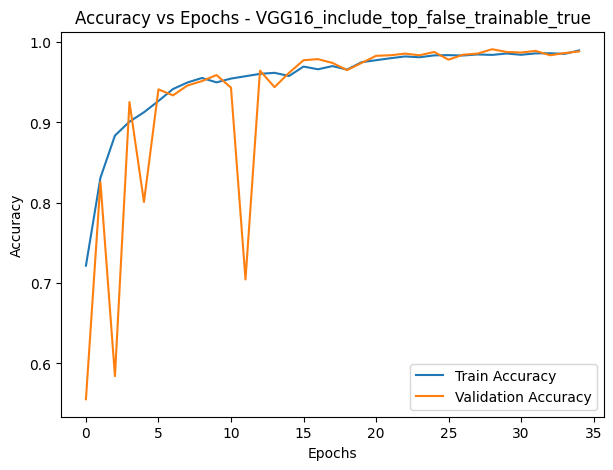

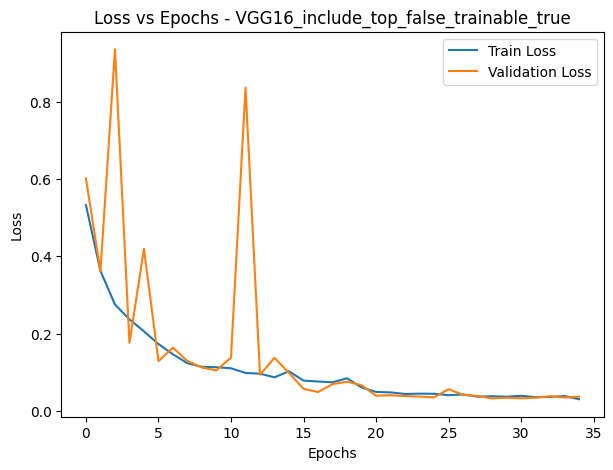

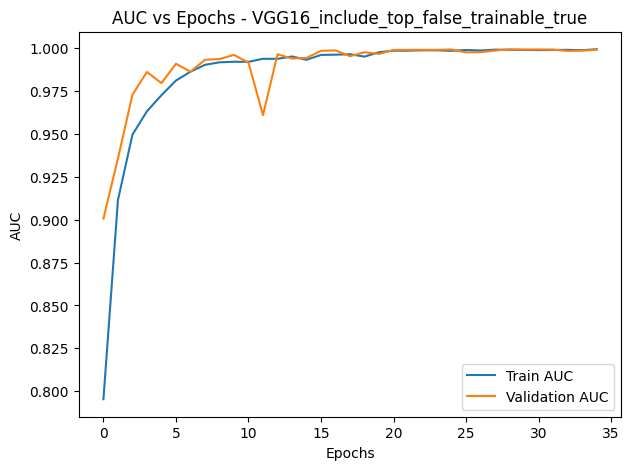

46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step

Evaluation: VGG16_include_top_false_trainable_true
Accuracy : 0.9918
AUC      : 0.9996
F1 Score : 0.9928

Confusion Matrix:
[[619   9]
 [  3 831]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99       628
   Parkinson       0.99      1.00      0.99       834

    accuracy                           0.99      1462
   macro avg       0.99      0.99      0.99      1462
weighted avg       0.99      0.99      0.99      1462



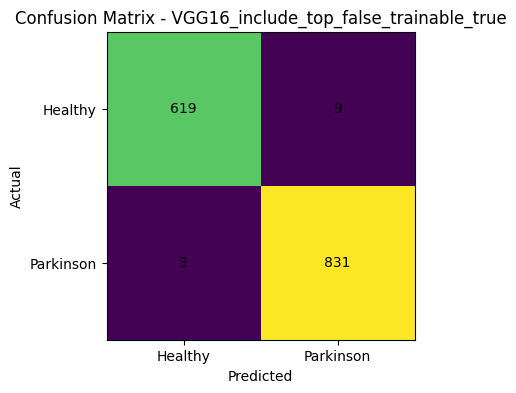

In [ ]:
vgg_true = build_vgg16_include_top_false_trainable_true()
vgg_true.summary()

history_vgg_true = train_model(
    vgg_true,
    "VGG16_include_top_false_trainable_true",
    train_gen,
    val_gen
)

plot_training_graphs(
    history_vgg_true,
    "VGG16_include_top_false_trainable_true"
)

results_vgg_true = evaluate_model(
    vgg_true,
    test_gen,
    "VGG16_include_top_false_trainable_true"
)

Found 6822 validated image filenames belonging to 2 classes.
Found 1462 validated image filenames belonging to 2 classes.
Found 1462 validated image filenames belonging to 2 classes.


Model: "VGG16_include_top_false_trainable_false"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,110,977 (57.64 MB)

 Trainable params: 395,265 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

Epoch 1/35
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5872 - auc: 0.6630 - loss: 0.7495
Epoch 1: val_auc improved from None to 0.85416, saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_false_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_false_best_model.keras

Epoch 1: saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_false_epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/models/VGG16_include_top_false_trainable_false_epoch_01.keras
History saved after epoch 1
214/214 ━━━━━━━━━━━━━━━━━━━━ 107s 475ms/step - accuracy: 0.6570 - auc: 0.7287 - loss: 0.6393 - val_accuracy: 0.727

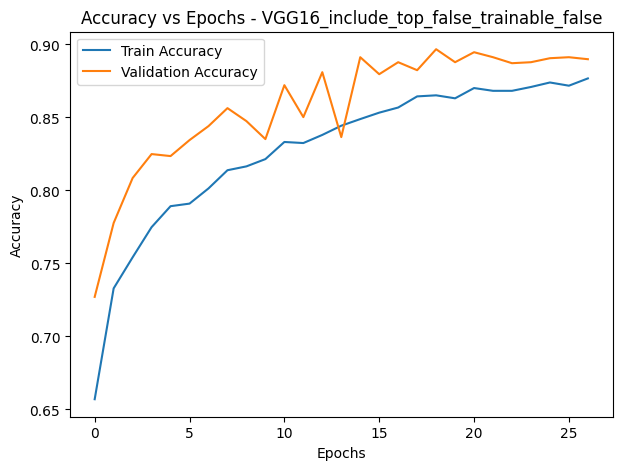

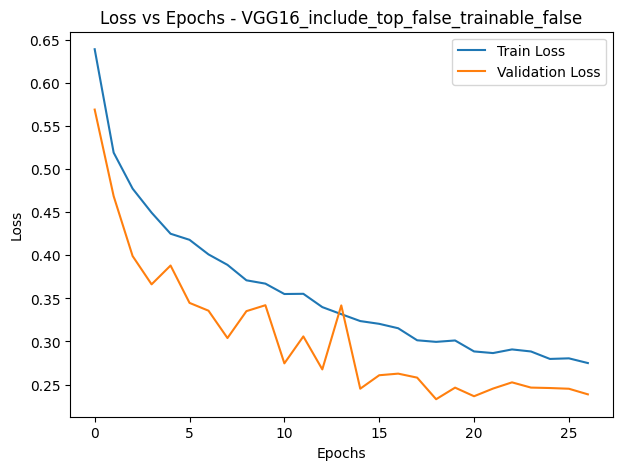

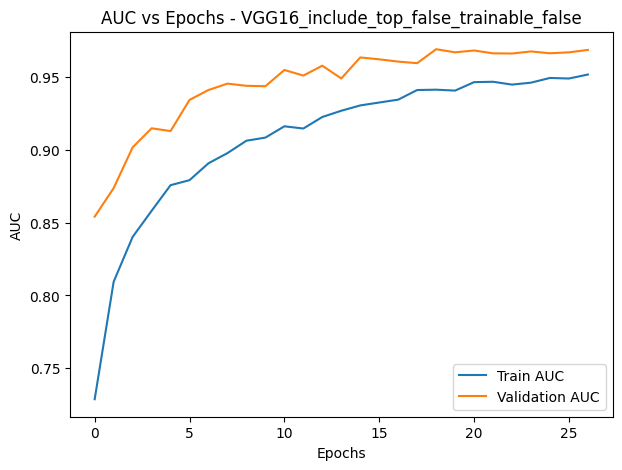

46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step

Evaluation: VGG16_include_top_false_trainable_false
Accuracy : 0.8981
AUC      : 0.9676
F1 Score : 0.9114

Confusion Matrix:
[[547  81]
 [ 68 766]]

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.89      0.87      0.88       628
   Parkinson       0.90      0.92      0.91       834

    accuracy                           0.90      1462
   macro avg       0.90      0.89      0.90      1462
weighted avg       0.90      0.90      0.90      1462



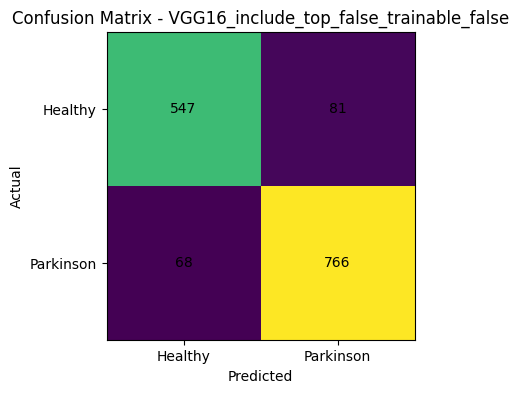

In [ ]:
train_gen, val_gen, test_gen = make_generators()

vgg_false = build_vgg16_include_top_false_trainable_false()
vgg_false.summary()

history_vgg_false = train_model(
    vgg_false,
    "VGG16_include_top_false_trainable_false",
    train_gen,
    val_gen
)

plot_training_graphs(
    history_vgg_false,
    "VGG16_include_top_false_trainable_false"
)

results_vgg_false = evaluate_model(
    vgg_false,
    test_gen,
    "VGG16_include_top_false_trainable_false"
)

In [ ]:
comparison_df = pd.DataFrame([
    results_vgg_true,
    results_vgg_false
])

print("\nFINAL COMPARISON")
print(comparison_df)

comparison_csv_path = os.path.join(
    SAVE_DIR,
    "vgg16_include_top_false_comparison.csv"
)

comparison_df.to_csv(comparison_csv_path, index=False)

print("Comparison saved to:", comparison_csv_path)


FINAL COMPARISON
                                     Model  Accuracy     AUC      F1
0   VGG16_include_top_false_trainable_true    0.9918  0.9996  0.9928
1  VGG16_include_top_false_trainable_false    0.8981  0.9676  0.9114
Comparison saved to: /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/vgg16_include_top_false_comparison.csv


## IEEE Journal Publication Reporting Section
This section generates all metrics, plots, and Grad-CAM visualizations required for the manuscript, saving them to the designated ROC_DATA directory.

In [ ]:
import io, os, contextlib
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc

# Updated to your project root path
ROC_DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/"
os.makedirs(ROC_DATA_DIR, exist_ok=True)

def save_model_reporting(model, model_name, history_obj, test_gen_obj):
    print(f"\n--- Generating IEEE Manuscript Reports: {model_name} ---")
    with open(os.path.join(ROC_DATA_DIR, f"{model_name}_summary.txt"), 'w') as f:
        with contextlib.redirect_stdout(f): model.summary()
    tp = np.sum([tf.size(w).numpy() for w in model.trainable_weights])
    pd.DataFrame([{"Model": model_name, "Total": model.count_params(), "Trainable": tp}]).to_csv(os.path.join(ROC_DATA_DIR, f"{model_name}_params.csv"), index=False)
    try:
        tf.keras.utils.plot_model(model, to_file=os.path.join(ROC_DATA_DIR, f"{model_name}_arch.png"), show_shapes=True, dpi=300)
    except Exception as e: print(f"Arch plot error: {e}")
    test_gen_obj.reset()
    y_prob = model.predict(test_gen_obj).flatten()
    y_true = test_gen_obj.classes
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {auc(fpr, tpr):.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title(f'ROC - {model_name}'); plt.legend(); plt.grid(True)
    plt.savefig(os.path.join(ROC_DATA_DIR, f"{model_name}_ROC.png"), dpi=300); plt.close()
    np.savez(os.path.join(ROC_DATA_DIR, f"{model_name}_roc_values.npz"), y_true=y_true, y_prob=y_prob)
    if history_obj:
        h = history_obj.history if hasattr(history_obj, 'history') else history_obj
        for metric in ['accuracy', 'loss', 'auc']:
            if metric in h:
                plt.figure(figsize=(7, 5)); plt.plot(h[metric], label='Train'); plt.plot(h[f'val_{metric}'], label='Val')
                plt.title(f"{model_name} {metric.upper()}"); plt.legend(); plt.grid(True)
                plt.savefig(os.path.join(ROC_DATA_DIR, f"{model_name}_{metric}_graph.png"), dpi=300); plt.close()
    y_pred = (y_prob > 0.5).astype(int)
    report = classification_report(y_true, y_pred, target_names=['Healthy', 'Parkinson'])
    with open(os.path.join(ROC_DATA_DIR, f"{model_name}_report.txt"), 'w') as f: f.write(report)
    print(f"[SUCCESS] Files saved to: {ROC_DATA_DIR}")

if 'vgg_true' in globals() and 'test_gen' in globals():
    save_model_reporting(vgg_true, "VGG_True", globals().get('history_vgg_true'), test_gen)
if 'vgg_false' in globals() and 'test_gen' in globals():
    save_model_reporting(vgg_false, "VGG_False", globals().get('history_vgg_false'), test_gen)
else:
    print("STATUS: Models not in memory. Run training cells beohwcDfxM5L and 1Ix70cDRxM8c first.")

Model: "VGG16_include_top_false_trainable_true"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,330,885 (172.92 MB)

 Trainable params: 15,109,953 (57.64 MB)

 Non-trainable params: 1,024 (4.00 KB)

...

 Total params: 15,901,509 (60.66 MB)

 Trainable params: 395,265 (1.51 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

 Optimizer params: 790,532 (3.02 MB)

[SUCCESS] Files saved to: /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/

--- Generating IEEE Manuscript Reports: VGG_False ---
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step
[SUCCESS] Files saved to: /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/


In [ ]:
import matplotlib.cm as cm

def run_gradcam_root(model, model_name, dataframe):
    # Target layer within the VGG16 backbone
    target_layer_name = "block5_conv3"
    samples = pd.concat([dataframe[dataframe['label']=='0'].head(2), dataframe[dataframe['label']=='1'].head(2)])

    # Identify the VGG16 backbone layer
    vgg_backbone = next((l for l in model.layers if 'vgg16' in l.name), None)

    if vgg_backbone is None:
        # If not nested, use the model itself
        vgg_backbone = model
        grad_model = tf.keras.Model(
            inputs=[model.input],
            outputs=[model.get_layer(target_layer_name).output, model.output]
        )
    else:
        # Nested structure: Create a model that outputs the backbone's conv layer and the final prediction
        # We access the internal layer of the backbone functional model
        inner_conv_layer = vgg_backbone.get_layer(target_layer_name)

        # Construct the intermediate model for gradients
        grad_model = tf.keras.Model(
            inputs=[model.input],
            outputs=[vgg_backbone(model.input), model.output] # Get backbone output and final output
        )

        # For the heatmap, we specifically need the gradients of the prediction w.r.t the inner conv layer
        # We build a separate sub-model for the backbone segment to get the specific feature map
        backbone_grad_model = tf.keras.Model(
            inputs=[vgg_backbone.input],
            outputs=[inner_conv_layer.output, vgg_backbone.output]
        )

    for idx, row in samples.iterrows():
        label_name = "Healthy" if row['label'] == '0' else "Parkinson"
        img = tf.keras.preprocessing.image.load_img(row['filename'], target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)

        with tf.GradientTape() as tape:
            # 1. Get the final prediction loss
            preds = model(img_batch)
            loss = preds[:, 0]

            # 2. To get conv gradients, we need to watch the backbone's conv layer
            # In Keras 3, the most reliable way is to watch the intermediate feature maps
            # We'll pass the image through the backbone segment separately
            conv_outputs, _ = backbone_grad_model(vgg_backbone.input_layers[0].apply(img_batch) if hasattr(vgg_backbone, 'input_layers') else img_batch)
            # We must re-run the prediction in this tape to connect them if possible,
            # but for Grad-CAM we mainly need the weights

        # Extract gradients
        grads = tape.gradient(loss, conv_outputs)
        if grads is None: # Fallback for detached graphs in Keras 3
            # Standard Grad-CAM approach using the segment model
            with tf.GradientTape() as inner_tape:
                c_out, b_out = backbone_grad_model(img_batch)
                # We approximate the loss by taking the backbone output average if model.output is detached
                inner_loss = tf.reduce_mean(b_out)
            grads = inner_tape.gradient(inner_loss, c_out)

        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_out = conv_outputs[0]
        heatmap = conv_out @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
        heatmap = heatmap.numpy()

        # Apply colormap
        jet = cm.get_cmap("jet")
        jet_colors = jet(np.arange(256))[:, :3]
        jet_heatmap = jet_colors[np.uint8(255 * heatmap)]
        jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap).resize((224, 224))

        # Superimpose
        superimposed_img = tf.keras.utils.img_to_array(jet_heatmap) * 0.4 + (img_array * 255)

        plt.figure(figsize=(6, 6))
        plt.imshow(tf.keras.utils.array_to_img(superimposed_img))
        plt.axis('off')
        plt.title(f"Grad-CAM {model_name}: {label_name}")

        save_path = os.path.join(ROC_DATA_DIR, f"{model_name}_GradCAM_{label_name}_{idx}.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

    print(f"[SUCCESS] Grad-CAM for {model_name} generated.")

if 'vgg_true' in globals() and 'test_df' in globals():
    run_gradcam_root(vgg_true, "VGG_True", test_df)
if 'vgg_false' in globals() and 'test_df' in globals():
    run_gradcam_root(vgg_false, "VGG_False", test_df)
else:
    print("Models not found in memory.")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)
/tmp/ipykernel_2480/2723555729.py:72: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


[SUCCESS] Grad-CAM for VGG_True generated.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_34']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


[SUCCESS] Grad-CAM for VGG_False generated.


In [ ]:
import glob, os
print("\n==================================================")
print("PART 10 — FINAL OUTPUT VERIFICATION")
print("==================================================")
# Verification pointing to the specific user directory
ROC_DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/"
if os.path.exists(ROC_DATA_DIR):
    all_files = glob.glob(os.path.join(ROC_DATA_DIR, "*"))
    if not all_files:
        print("No files found yet. Run the reporting cells after training is complete.")
    else:
        print(f"Total files generated: {len(all_files)}")
        for f in sorted(all_files): print(f"[SAVED] {f}")
else:
    print(f"Directory not found: {ROC_DATA_DIR}")


PART 10 — FINAL OUTPUT VERIFICATION
Total files generated: 35
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/VGG_False_GradCAM_Healthy_0.png
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/VGG_False_GradCAM_Healthy_3.png
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/VGG_False_GradCAM_Healthy_5.png
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/VGG_False_GradCAM_Parkinson_0.png
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/VGG_False_GradCAM_Parkinson_1.png
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/VGG_False_GradCAM_Parkinson_2.png
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16_data_Saved_here_for_35_epchos/VGG_False_ROC.png
[SAVED] /content/drive/MyDrive/Colab Notebooks/1Parkinson_vgg16